# 09 — Interactive dashboard artifacts


In [15]:
from pathlib import Path
import sys

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import folium
import plotly.express as px
import plotly.graph_objects as go

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MAP_DIR = OUTPUT_DIR / "maps"

MAP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Visualization output:", MAP_DIR)


Project root: /Users/subhankarbiswas/smart-city-knowledge-graph-v3
Visualization output: /Users/subhankarbiswas/smart-city-knowledge-graph-v3/outputs/maps


In [16]:
POI_PATH = PROCESSED_DIR / "pois_clean.parquet"
ACCESSIBILITY_PATH = PROCESSED_DIR / "network_accessibility.csv"
COVERAGE_PATH = PROCESSED_DIR / "accessibility_coverage.csv"

KMEANS_PATH = PROCESSED_DIR / "accessibility_profiles.csv"
DBSCAN_PATH = PROCESSED_DIR / "accessibility_profiles_dbscan.csv"

if not POI_PATH.exists():
    raise FileNotFoundError(f"Missing POI dataset: {POI_PATH}")

pois = gpd.read_parquet(POI_PATH)

print(f"POIs loaded: {len(pois):,}")
print("\nPOI columns:")
print(pois.columns.tolist())

if ACCESSIBILITY_PATH.exists():
    accessibility = pd.read_csv(ACCESSIBILITY_PATH)
else:
    accessibility = pd.DataFrame()

if COVERAGE_PATH.exists():
    coverage = pd.read_csv(COVERAGE_PATH)
else:
    coverage = pd.DataFrame()

print(f"\nAccessibility records: {len(accessibility):,}")
print(f"Coverage records: {len(coverage):,}")

POIs loaded: 224

POI columns:
['element', 'id', 'geometry', 'amenity', 'contact:fax', 'contact:phone', 'contact:website', 'emergency', 'healthcare', 'internet_access', 'name', 'opening_hours', 'operator', 'wheelchair', 'service_type', 'addr:city', 'addr:country', 'addr:housenumber', 'addr:postcode', 'addr:street', 'dispensing', 'website', 'wheelchair:description', 'addr:suburb', 'check_date:opening_hours', 'contact:whatsapp', 'email', 'phone', 'image', 'ref', 'school:de', 'source', 'source:position', 'building', 'building:levels', 'roof:levels', 'roof:shape', 'isced:level', 'wikidata', 'addr:housename', 'note', 'brand', 'brand:wikidata', 'shop', 'toilets:wheelchair', 'surveillance', 'brand:wikipedia', 'description', 'new_name', 'alt_name', 'platforms', 'public_transport', 'railway', 'railway:ref', 'ref:ibnr', 'train', 'uic_ref', 'wikipedia', 'bus', 'highway', 'network', 'network:guid', 'network:short', 'network:wikidata', 'network:wikipedia', 'bench', 'bin', 'shelter', 'lit', 'tactile

In [17]:
pois["service_type"] = (
    pois["service_type"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

if not accessibility.empty:
    accessibility["service"] = (
        accessibility["service"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    accessibility["travel_time_min"] = pd.to_numeric(
        accessibility["travel_time_min"],
        errors="coerce",
    )

    accessibility = accessibility.dropna(
        subset=["travel_time_min"]
    )

if not coverage.empty:
    coverage["service"] = (
        coverage["service"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

print("POIs:", len(pois))
print("Accessibility:", len(accessibility))
print("Coverage:", len(coverage))

POIs: 224
Accessibility: 110
Coverage: 15


### 1. Interactive POI service distribution ###

In [18]:
poi_counts = (
    pois["service_type"]
    .value_counts()
    .reset_index()
)

poi_counts.columns = ["service_type", "count"]

fig = px.bar(
    poi_counts,
    x="service_type",
    y="count",
    title="POI Distribution by Service Type",
    labels={
        "service_type": "Service type",
        "count": "Number of POIs",
    },
    hover_data=["count"],
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
)

fig.show()

fig.write_html(
    MAP_DIR / "poi_service_distribution.html",
    include_plotlyjs="cdn",
)

### 2. Interactive POI map ###

In [19]:
if pois.crs is None:
    raise ValueError("POI dataset has no CRS.")

pois_wgs84 = pois.to_crs(4326)

center = [
    pois_wgs84.geometry.y.mean(),
    pois_wgs84.geometry.x.mean(),
]

poi_map = folium.Map(
    location=center,
    zoom_start=14,
    tiles="OpenStreetMap",
)

service_groups = {}

for service in sorted(pois_wgs84["service_type"].unique()):
    group = folium.FeatureGroup(
        name=service.title(),
        show=True,
    )

    service_data = pois_wgs84[
        pois_wgs84["service_type"] == service
    ]

    for _, row in service_data.iterrows():

        geometry = row.geometry

        if geometry is None or geometry.is_empty:
            continue

        point = geometry.centroid

        popup_text = (
            f"<b>Service:</b> {service.title()}<br>"
            f"<b>Latitude:</b> {point.y:.6f}<br>"
            f"<b>Longitude:</b> {point.x:.6f}"
        )

        folium.CircleMarker(
            location=[point.y, point.x],
            radius=5,
            popup=folium.Popup(
                popup_text,
                max_width=300,
            ),
            fill=True,
            fill_opacity=0.7,
        ).add_to(group)

    group.add_to(poi_map)
    service_groups[service] = group

folium.LayerControl(
    collapsed=False,
).add_to(poi_map)

poi_map.save(
    MAP_DIR / "poi_map.html"
)

print(
    f"Saved interactive POI map: "
    f"{MAP_DIR / 'poi_map.html'}"
)

Saved interactive POI map: /Users/subhankarbiswas/smart-city-knowledge-graph-v3/outputs/maps/poi_map.html


### 3. Interactive travel-time distribution ###

In [20]:
if accessibility.empty:
    print("No accessibility data available.")
else:

    fig = px.histogram(
        accessibility,
        x="travel_time_min",
        color="service",
        marginal="box",
        barmode="overlay",
        opacity=0.65,
        title="Travel-Time Distribution by Target Service",
        labels={
            "travel_time_min": "Travel time (minutes)",
            "service": "Target service",
        },
    )

    fig.update_layout(
        height=650,
        legend_title="Service",
    )

    fig.show()

    fig.write_html(
        MAP_DIR / "travel_time_distribution.html",
        include_plotlyjs="cdn",
    )

### 4. Interactive service travel-time comparison ###

In [21]:
if accessibility.empty:
    print("No accessibility data available.")
else:

    service_summary = (
        accessibility
        .groupby("service")["travel_time_min"]
        .agg(
            mean="mean",
            median="median",
            minimum="min",
            maximum="max",
            records="count",
        )
        .reset_index()
    )

    service_summary["mean"] = service_summary["mean"].round(2)
    service_summary["median"] = service_summary["median"].round(2)

    display(service_summary)

    fig = px.bar(
        service_summary,
        x="service",
        y="mean",
        color="service",
        hover_data=[
            "median",
            "minimum",
            "maximum",
            "records",
        ],
        title="Average Travel Time to Each Service",
        labels={
            "service": "Target service",
            "mean": "Average travel time (minutes)",
        },
    )

    fig.update_layout(
        xaxis_tickangle=-45,
        showlegend=False,
        height=600,
    )

    fig.show()

    fig.write_html(
        MAP_DIR / "service_accessibility_bar.html",
        include_plotlyjs="cdn",
    )

,service,mean,median,minimum,maximum,records
0,hospital,24.17,23.82,7.004547,47.566936,22
1,library,21.71,21.40,5.663331,42.866146,22
2,pharmacy,12.84,10.18,2.655069,29.212488,22
3,supermarket,4.99,2.40,0.000000,14.051300,22
4,train_station,17.31,19.87,2.077791,32.643849,22


### 5. Interactive box plot ###

In [22]:
if accessibility.empty:
    print("No accessibility data available.")
else:

    fig = px.box(
        accessibility,
        x="service",
        y="travel_time_min",
        color="service",
        points="outliers",
        title="Travel-Time Distribution by Service",
        labels={
            "service": "Target service",
            "travel_time_min": "Travel time (minutes)",
        },
        hover_data=[
            "origin_index",
        ],
    )

    fig.update_layout(
        xaxis_tickangle=-45,
        showlegend=False,
        height=650,
    )

    fig.show()

    fig.write_html(
        MAP_DIR / "service_travel_time_boxplot.html",
        include_plotlyjs="cdn",
    )

### 6. Accessibility heatmap ###

In [23]:
if accessibility.empty:
    print("No accessibility data available.")
else:

    heatmap_data = accessibility.pivot_table(
        index="origin_index",
        columns="service",
        values="travel_time_min",
        aggfunc="mean",
    )

    heatmap_data = heatmap_data.sort_index()

    fig = px.imshow(
        heatmap_data,
        aspect="auto",
        color_continuous_scale="Viridis",
        title="Accessibility Heatmap: Origin vs Service",
        labels={
            "x": "Target service",
            "y": "Origin",
            "color": "Travel time (minutes)",
        },
    )

    fig.update_layout(
        height=700,
    )

    fig.show()

    fig.write_html(
        MAP_DIR / "accessibility_heatmap.html",
        include_plotlyjs="cdn",
    )

### 7. Mean accessibility profile ###

In [24]:
if accessibility.empty:
    print("No accessibility data available.")
else:

    profile = (
        accessibility
        .groupby("service")["travel_time_min"]
        .mean()
        .reset_index()
        .sort_values("travel_time_min")
    )

    fig = px.line(
        profile,
        x="service",
        y="travel_time_min",
        markers=True,
        title="Mean Travel Time Profile by Service",
        labels={
            "service": "Target service",
            "travel_time_min": "Mean travel time (minutes)",
        },
    )

    fig.update_layout(
        xaxis_tickangle=-45,
        height=550,
    )

    fig.show()

### 8. Accessibility Threshold Visualization ###

In [25]:
if coverage.empty:
    print("No coverage data available.")
else:

    coverage_columns = [
        column
        for column in coverage.columns
        if any(
            keyword in column.lower()
            for keyword in [
                "5",
                "10",
                "15",
                "coverage",
                "threshold",
            ]
        )
    ]

    print("Potential coverage columns:")
    print(coverage_columns)

    numeric_columns = coverage.select_dtypes(
        include="number"
    ).columns.tolist()

    print("\nNumeric columns:")
    print(numeric_columns)

Potential coverage columns:
['threshold_min', 'coverage_pct']

Numeric columns:
['threshold_min', 'origins', 'reached', 'coverage_pct']


In [26]:
coverage_plot_columns = [
    column
    for column in numeric_columns
    if column != "origin_index"
]

if coverage_plot_columns:

    coverage_long = coverage[
        ["service"] + coverage_plot_columns
    ].melt(
        id_vars="service",
        var_name="threshold",
        value_name="coverage",
    )

    fig = px.bar(
        coverage_long,
        x="service",
        y="coverage",
        color="threshold",
        barmode="group",
        title="Accessibility Coverage by Service and Threshold",
        labels={
            "service": "Service",
            "coverage": "Coverage",
            "threshold": "Threshold",
        },
    )

    fig.update_layout(
        xaxis_tickangle=-45,
        height=650,
    )

    fig.show()

    fig.write_html(
        MAP_DIR / "accessibility_coverage.html",
        include_plotlyjs="cdn",
    )

### 9. KMeans Cluster Visualization ###

In [27]:
if KMEANS_PATH.exists():
    
    kmeans = pd.read_csv(KMEANS_PATH)

    print("KMeans columns:")
    print(kmeans.columns.tolist())

    if "cluster_kmeans" in kmeans.columns:

        cluster_column = "cluster_kmeans"

        numeric_columns = [
            column
            for column in kmeans.columns
            if pd.api.types.is_numeric_dtype(kmeans[column])
            and column != cluster_column
        ]

        if len(numeric_columns) >= 2:

            x_column = numeric_columns[0]
            y_column = numeric_columns[1]

            fig = px.scatter(
                kmeans,
                x=x_column,
                y=y_column,
                color=cluster_column.astype(str)
                if hasattr(cluster_column, "astype")
                else cluster_column,
                title="KMeans Accessibility Clusters",
                labels={
                    x_column: x_column,
                    y_column: y_column,
                    cluster_column: "KMeans cluster",
                },
                hover_data=kmeans.columns.tolist(),
            )

            fig.update_layout(
                height=700,
            )

            fig.show()

            fig.write_html(
                MAP_DIR / "kmeans_clusters.html",
                include_plotlyjs="cdn",
            )

else:
    print("KMeans profile file not found.")

KMeans columns:
['hospital', 'library', 'pharmacy', 'supermarket', 'train_station', 'cluster_kmeans']


In [28]:
if KMEANS_PATH.exists():
    
    kmeans = pd.read_csv(KMEANS_PATH)

    if "cluster_kmeans" in kmeans.columns:

        kmeans["cluster_label"] = (
            kmeans["cluster_kmeans"]
            .astype(str)
        )

        numeric_columns = [
            column
            for column in kmeans.columns
            if pd.api.types.is_numeric_dtype(kmeans[column])
            and column not in [
                "cluster_kmeans",
            ]
        ]

        if len(numeric_columns) >= 2:

            x_column = numeric_columns[0]
            y_column = numeric_columns[1]

            fig = px.scatter(
                kmeans,
                x=x_column,
                y=y_column,
                color="cluster_label",
                title="KMeans Accessibility Clusters",
                labels={
                    x_column: x_column,
                    y_column: y_column,
                    "cluster_label": "Cluster",
                },
                hover_data=kmeans.columns.tolist(),
            )

            fig.update_layout(
                height=700,
            )

            fig.show()

            fig.write_html(
                MAP_DIR / "kmeans_clusters.html",
                include_plotlyjs="cdn",
            )

### 10. DBSCAN Cluster Visualization ###

In [29]:
if DBSCAN_PATH.exists():
    
    dbscan = pd.read_csv(DBSCAN_PATH)

    print("DBSCAN columns:")
    print(dbscan.columns.tolist())

    if "cluster_dbscan" in dbscan.columns:

        dbscan["cluster_label"] = (
            dbscan["cluster_dbscan"]
            .astype(str)
        )

        numeric_columns = [
            column
            for column in dbscan.columns
            if pd.api.types.is_numeric_dtype(dbscan[column])
            and column != "cluster_dbscan"
        ]

        if len(numeric_columns) >= 2:

            x_column = numeric_columns[0]
            y_column = numeric_columns[1]

            fig = px.scatter(
                dbscan,
                x=x_column,
                y=y_column,
                color="cluster_label",
                title="DBSCAN Accessibility Clusters",
                labels={
                    x_column: x_column,
                    y_column: y_column,
                    "cluster_label": "DBSCAN cluster",
                },
                hover_data=dbscan.columns.tolist(),
            )

            fig.update_layout(
                height=700,
            )

            fig.show()

            fig.write_html(
                MAP_DIR / "dbscan_clusters.html",
                include_plotlyjs="cdn",
            )

else:
    print("DBSCAN profile file not found.")

DBSCAN columns:
['hospital', 'library', 'pharmacy', 'supermarket', 'train_station', 'cluster_dbscan']


### 11. Interactive Cluster-Size Comparison ###

In [30]:
cluster_frames = []

if KMEANS_PATH.exists():
    kmeans = pd.read_csv(KMEANS_PATH)

    if "cluster_kmeans" in kmeans.columns:
        counts = (
            kmeans["cluster_kmeans"]
            .value_counts()
            .sort_index()
            .reset_index()
        )

        counts.columns = ["cluster", "count"]
        counts["method"] = "KMeans"

        cluster_frames.append(counts)

if DBSCAN_PATH.exists():
    dbscan = pd.read_csv(DBSCAN_PATH)

    if "cluster_dbscan" in dbscan.columns:
        counts = (
            dbscan["cluster_dbscan"]
            .value_counts()
            .sort_index()
            .reset_index()
        )

        counts.columns = ["cluster", "count"]
        counts["method"] = "DBSCAN"

        cluster_frames.append(counts)

if cluster_frames:

    cluster_sizes = pd.concat(
        cluster_frames,
        ignore_index=True,
    )

    cluster_sizes["cluster"] = (
        cluster_sizes["cluster"].astype(str)
    )

    fig = px.bar(
        cluster_sizes,
        x="cluster",
        y="count",
        color="method",
        barmode="group",
        title="Cluster Size Comparison",
        labels={
            "cluster": "Cluster",
            "count": "Number of origins",
            "method": "Clustering method",
        },
    )

    fig.show()

    fig.write_html(
        MAP_DIR / "cluster_size_comparison.html",
        include_plotlyjs="cdn",
    )

### 12. Static Summary Dashboard ###

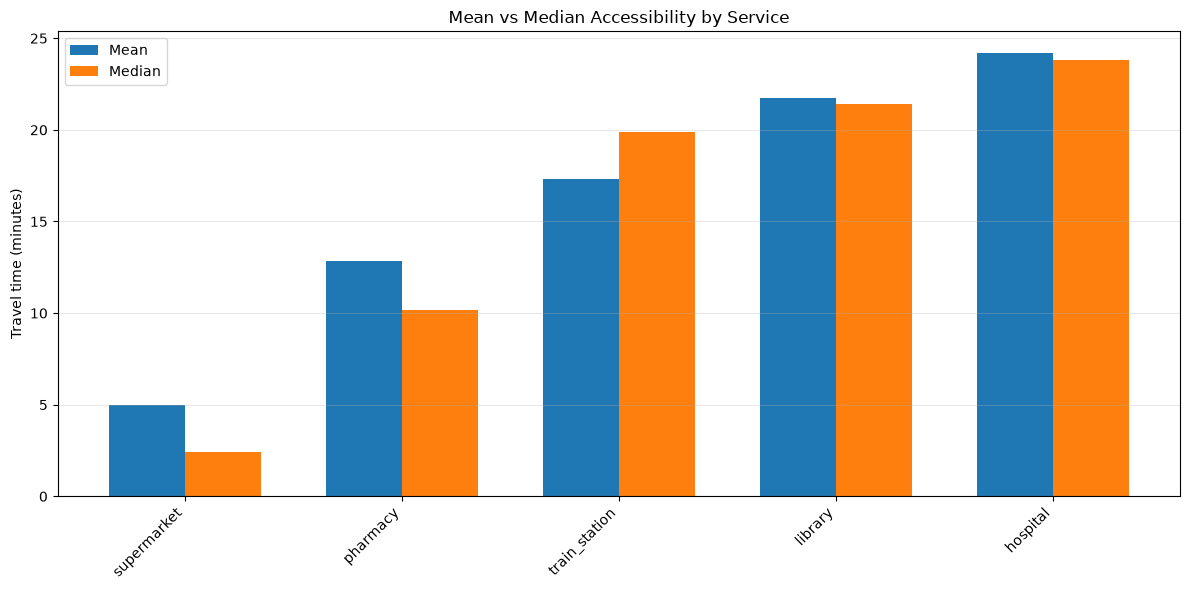

In [31]:
if not accessibility.empty:
    
    summary = (
        accessibility
        .groupby("service")["travel_time_min"]
        .agg(
            mean="mean",
            median="median",
        )
        .sort_values("mean")
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(summary))
    width = 0.35

    ax.bar(
        x - width / 2,
        summary["mean"],
        width,
        label="Mean",
    )

    ax.bar(
        x + width / 2,
        summary["median"],
        width,
        label="Median",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        summary.index,
        rotation=45,
        ha="right",
    )

    ax.set_ylabel("Travel time (minutes)")
    ax.set_title(
        "Mean vs Median Accessibility by Service"
    )

    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    fig.savefig(
        MAP_DIR / "mean_vs_median_accessibility.png",
        dpi=200,
        bbox_inches="tight",
    )

In [32]:
print("\n" + "=" * 70)
print("VISUALIZATION OUTPUTS")
print("=" * 70)

for path in sorted(MAP_DIR.iterdir()):

    if path.is_file():

        size_kb = path.stat().st_size / 1024

        print(
            f"✓ {path.name:<45} "
            f"{size_kb:>8.1f} KB"
        )

print("\nVisualization directory:")
print(MAP_DIR)


VISUALIZATION OUTPUTS
✓ .gitkeep                                           0.0 KB
✓ accessibility_coverage.html                       10.6 KB
✓ accessibility_heatmap.html                         9.6 KB
✓ cluster_size_comparison.html                       8.5 KB
✓ dbscan_clusters.html                               9.9 KB
✓ kmeans_clusters.html                              11.5 KB
✓ mean_vs_median_accessibility.png                  59.6 KB
✓ poi_map.html                                     251.9 KB
✓ poi_service_distribution.html                      8.1 KB
✓ service_accessibility_bar.html                    10.9 KB
✓ service_travel_time_boxplot.html                  13.0 KB
✓ travel_time_distribution.html                     13.7 KB

Visualization directory:
/Users/subhankarbiswas/smart-city-knowledge-graph-v3/outputs/maps
